In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Master dataset load 
df = pd.read_csv('extracted_data/master_dataset.csv',
                  parse_dates=['order_purchase_timestamp'])

print("Data loaded")


Data loaded


In [3]:
print(df.shape)


(118434, 31)


In [13]:
# Reference date — 
reference_date = df['order_purchase_timestamp'].max()
print(reference_date)

#  calculate RFM

# Recency ->  he is Recent customer or not . 
# Frequency ->  Q. it's a Loyal Customer ?
# Monetary -> how much spend money, Q. Valuable Customer ?
rfm = df.groupby('customer_id').agg(
    Recency=('order_purchase_timestamp', 
              lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum')
).reset_index()

print("RFM Calculated")
print(rfm.head(10))
print(rfm.shape)

2018-10-17 17:30:18
RFM Calculated
                        customer_id  Recency  Frequency  Monetary
0  00012a2ce6f8dcda20d059ce98491703      337          1    114.74
1  000161a058600d5901f007fab4c27140      458          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079      596          1    195.42
3  0002414f95344307404f0ace7a26f1d5      427          1    179.35
4  000379cdec625522490c315e70c7a9fb      198          1    107.01
5  0004164d20a9e969af783496f3408652      553          1     71.80
6  000419c5494106c306a97b5635748086      228          1     49.40
7  00046a560d407e99b969756e0b10f282      303          1    166.59
8  00050bf6e01e69d5c0fd612f1bcfb69c      395          1     85.23
9  000598caf2ef4117407665ac33275130       67          1   1255.71
(99441, 4)


In [38]:
# Recency --> 
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])

# Frequency -- 
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 
                          q=5, labels=[1,2,3,4,5])

# Monetary -- 
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])


rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


def assign_segment(r, f, m):
    
    r, f, m = int(r), int(f), int(m)
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion '      
    elif r >= 3 and f >= 3:
        return 'Loyal '         
    elif r >= 4 and f <= 2:
        return 'New Customer' 
    elif r <= 2 and f >= 3:
        return 'At Risk '      
    elif r <= 2 and f <= 2:
        return 'Lost '         
    else:
        return 'Potential '     

rfm['Segment'] = rfm.apply(
    lambda x: assign_segment(x['R_Score'], x['F_Score'], x['M_Score']), axis=1)

print(" RFM Segments Ready!")
print("\n Segment Distribution:")
print(rfm['Segment'].value_counts())

 RFM Segments Ready!

 Segment Distribution:
Segment
Loyal           29259
At Risk         23923
New Customer    16052
Lost            15728
Potential        7997
Champion         6482
Name: count, dtype: int64


In [39]:
rfm['Segment']

0               Lost 
1               Lost 
2               Lost 
3               Lost 
4        New Customer
             ...     
99436          Loyal 
99437          Loyal 
99438       Champion 
99439        At Risk 
99440        At Risk 
Name: Segment, Length: 99441, dtype: object

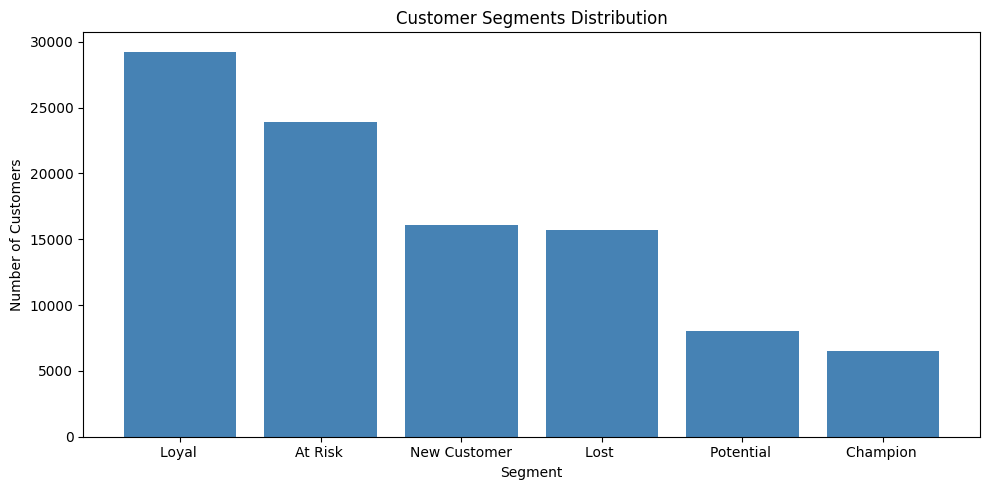


 Segment wise Revenue:
Segment
At Risk         4884877.26
Loyal           4724581.59
Lost            3380518.69
New Customer    3360669.21
Champion        2643838.44
Potential       1476241.47
Name: Monetary, dtype: float64


In [45]:
# this chart shows :—
# How many Champions vs Lost customers
# which sagment is generated more revenue.
# CEO ko kahan focus karna chahiye!

# Segment distribution plot
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(segment_counts.index, 
        segment_counts.values,
        color='steelblue')
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("\n Segment wise Revenue:")
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
print(segment_revenue)

In [41]:
print(rfm.groupby('Segment')['Monetary'].sum())


Segment
At Risk         4884877.26
Champion        2643838.44
Lost            3380518.69
Loyal           4724581.59
New Customer    3360669.21
Potential       1476241.47
Name: Monetary, dtype: float64


In [46]:
rfm['Monetary']

0        114.74
1         67.41
2        195.42
3        179.35
4        107.01
          ...  
99436     81.36
99437     63.13
99438    214.13
99439     91.00
99440     18.37
Name: Monetary, Length: 99441, dtype: float64

In [54]:
# RFM data save karo
rfm.to_csv('extracted_data/rfm_segments.csv', index=False)

print(" RFM data saved ")
print(f"Shape:\n {rfm.shape}")
print(f"Columns:\n {list(rfm.columns)}")
# print(f"\nSegment Distribution:")
print("\n",rfm['Segment'].value_counts())

 RFM data saved 
Shape:
 (99441, 9)
Columns:
 ['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']

 Segment
Loyal           29259
At Risk         23923
New Customer    16052
Lost            15728
Potential        7997
Champion         6482
Name: count, dtype: int64
